This is a small tutorial on linear regression. The word "regression" means reverting to a a more basic or a previous state, than the current one. For us in data analysis regression means fitting a set of readings or points on the x-y plane to a straight line. We do not care for all the details we just regress to a straight line fit. 

The problem is given a set of readings

$y_i = f(x_i) \mbox{for all } i = 1 \cdots N$

We want to minimize

$\displaystyle\sum_i|y_i - \hat{y}_i|^2$

where $\hat{y}_i = a + bx_i$ and we want to choose $a$ and $b$ such that

$\displaystyle\chi^2 = \underset{a,b}{\text{minimize}}\sum_i|y_i - (a + bx_i)|^2$

Doing 

$\displaystyle \frac{\partial\chi^2}{\partial a} = -2\sum_{i = 1}^N(y_i - a - bx_i) = 0$

$\displaystyle \frac{\partial\chi^2}{\partial b} = -2\sum_{i = 1}^Nx_i(y_i - a - bx_i) = 0$

For convenience we use the following notation

$S = N$ 

$S_x = \displaystyle\sum_{i = 1}^{N}x_i$

$S_y = \displaystyle\sum_{i = 1}^Ny_i$

$S_{xx} = \displaystyle\sum_{i = 1}^Nx_i^2$

$S_{xy} = \displaystyle\sum_{i = 1}^Nx_iy_i$

With these definition the equations for minimization become

$aS + bS_x = S_y$

$aS_x + bS_{xx} = S_{xy}$

The solutions for $a$ and $b$ for the system of two equations are

$ a = \displaystyle\frac{S_{xx}S_y - S_xS_{xy}}{\Delta}$

$b = \displaystyle\frac{SS_{xy} - S_xS_y}{\Delta}$

$\Delta = SS_{xx} - (S_x)^2$






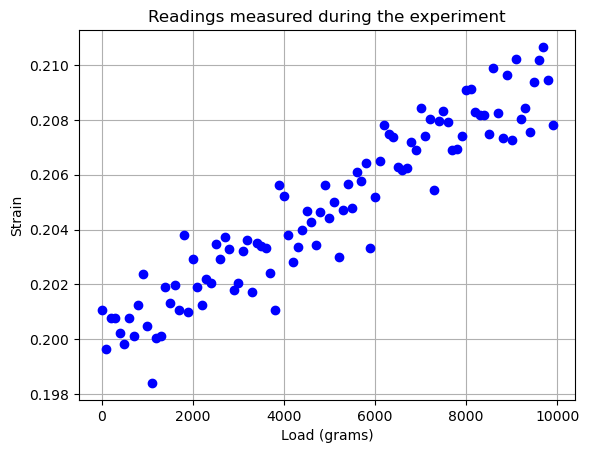

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Generate Artificial data
number_of_loads = 100
load_gms = np.arange(number_of_loads)*100
offset_error = 2e-1
strains = load_gms*(1e-6) + offset_error

# Generate fake noise (for the sake of simulations
mean = 0
noise_power = 1e-6
std_dev = math.sqrt(noise_power)
measurement_noise = np.random.normal(mean,std_dev,number_of_loads)
strain_readings = strains + measurement_noise 

plt.figure()
plt.plot(load_gms,strain_readings,'bo')
plt.xlabel('Load (grams)')
plt.ylabel('Strain')
plt.title('Readings measured during the experiment')
plt.grid(True)


In [31]:
# Now we do the estimate for the intercept (a) and slope (b)

N = number_of_loads
x = load_gms
y = strain_readings

S = N
S_x = np.sum(x)
S_y = np.sum(y)
S_xx = np.sum(x**2)
S_xy = np.sum(x*y)

# The solution
Delta = S*S_xx - (S_x)**2
intercept = (S_xx*S_y - S_x*S_xy)/(Delta)
slope = (S*S_xy - S_x*S_y)/(Delta)

print(f'The estimated values are intercept = {intercept} and slope = {slope}')


The estimated values are intercept = 0.19990172465097195 and slope = 9.895127052930008e-07


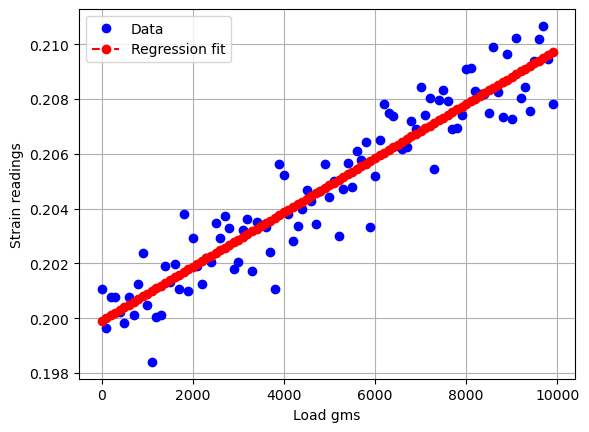

In [32]:
# Plot it and see
reconstruct_soln = intercept + slope*load_gms

fig,ax = plt.subplots()
ax.plot(load_gms,strain_readings,'bo',label='Data')
ax.plot(load_gms,reconstruct_soln,'r--o',label='Regression fit')
ax.set_xlabel('Load gms')
ax.set_ylabel('Strain readings')
ax.legend()
ax.grid(True)
plt.show()



Now how good is the regression fit ? How much of the variability does the straight line explain ? 

For this we use the $R^2$ measure which is

$R^2 = \frac{\mbox{Sum of Squares of the Regression Fit}}{\mbox{Sum of Squares of the original data}}$


The other kind of question to be asked is 'Is there statisical evidence to accept the line fit ?' This is answered via statistical tests. There are two ways of testing this.

 The first one is an F test which uses the ratio fo the variances before and after the regression fit
   
   $F = \frac{\mbox{Mean Square of Regression Fit}}{\mbox{Mean Square of the Residual fit}}$

   The mean square of the regression fit is

   $\mbox{MS Regression fit} = \displaystyle\frac{\sum_i(\hat{Y}_i - \displaystyle\frac{1}{N}Y_i)^2}{DOF_{regression}}$

   $\nu_1 = DOF_{regression} = 1$
   
   and the mean square of the residual fit is calculated by first doing

   Sum of squares of Residual fit = $\displaystyle\sum_i(Y_i - \displaystyle\frac{1}{N}\sum_iY_i)^2 - \sum_i(\hat{Y}_i - \displaystyle\frac{1}{N}\sum_iY_i)^2$

   and then doing

   $\mbox{MS Residual fit} = \frac{\mbox{Sum of Squares of Residual fit}}{\displaystyle DOF_{residual}}$

   $\nu_2 = DOF_{residual} = N - 2$

   The F statistic is then used to contest two hypotheses

\begin{align*}
  H_0: b &= 0 \\
  H_1: b &\neq 0
\end{align*}

\begin{align*}
F & \underset{H_0}{\overset{H_1}{\gtrless}} & F_{\alpha(1),\nu_1,\nu_2}
\end{align*}

   
   

In [34]:
# Now for the code
import scipy.stats as stats

sum_squares_regression = np.sum((reconstruct_soln - np.mean(y))**2)
dof_regression = 1
nu_1 = dof_regression
sum_squares_total = np.sum((y - np.mean(y))**2)
ss_residual = sum_squares_total - sum_squares_regression
dof_residual = N - 2
nu_2 = dof_residual

ms_residual = ss_residual/dof_residual

ms_regression = sum_squares_regression/dof_regression

F = ms_regression/ms_residual

R_squared = sum_squares_regression / sum_squares_total
print(f'R squared = {R_squared*100} %')

print(f'The computed F statistic is {F}')
alpha = 0.05 # 5 % siginificance level

F_alpha = stats.f.ppf(1 - alpha,nu_1,nu_2)
print(f'The value of F_alpha = {F_alpha}')

if(F > F_alpha):
    print(f'Null hypothesis rejected, accept line fit at alpha = {alpha} siginificance level')
else:
    print('Inconclusive evidence to accept line fit')
    




R squared = 89.16931493612242 %
The computed F statistic is 806.836577021788
The value of F_alpha = 3.9381110780033644
Null hypothesis rejected, accept line fit at alpha = 0.05 siginificance level


The second type of test uses the standard error of the slope

$s_b = \sqrt{\frac{\mbox{MS Residual Fit}}{\displaystyle\sum_i(x_i - \frac{1}{N}\sum x_i)^2}}$

and then the t-test involves computing

$t = \frac{\mbox{parameter estimate - parameter value hypothesized}}{\displaystyle s_b}$

The degrees of freedom used for calculating this t test is $N - 2$



In [22]:
# t-test to test the hypothesis that the slope = 0 versus against

standard_error = np.sqrt(ms_residual/np.sum((x - np.mean(x))**2))
print(f' The Standard Error is {standard_error}')

t = abs((slope - 0)/standard_error)

ttest_dof = N - 2
t_crit = stats.t.ppf(1 - alpha/2, ttest_dof)
print(f' The minimum t is {t_crit}, but from the estimate t is {t}')

if(t > t_crit):
    print(f'Null hypothesis rejected for T Test, accept line fit at alpha = {alpha} siginificance level')
else:
    print('Inconclusive evidence to accept line fit')
    




 The Standard Error is 3.266948182526471e-06
 The minimum t is 1.984467454426692, but from the estimate t is 1.2861307595268263
Inconclusive evidence to accept line fit


Hey but $F = t^2$. Check !